# 🔗 Hands-On Bab 4 — Analisis Jaringan Level Simpul
### Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi

Notebook ini mereproduksi seluruh contoh perhitungan **degree, betweenness, closeness,** dan **eigenvector centrality** dari buku, lengkap dengan **Latihan Soal Bab 4**.

In [1]:
!pip install -q networkx matplotlib pandas
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

## 4.1.1 Degree Centrality

Reproduksi Gambar 4.1: graf bintang berpusat di A, dengan 4 simpul lain. Buku: C_D(A) = 4/4 = 1.0, C_D(B) = 2/4 = 0.5.

C_D(A) = 1.000
C_D(B) = 0.500
C_D(C) = 0.500
C_D(D) = 0.250
C_D(E) = 0.250


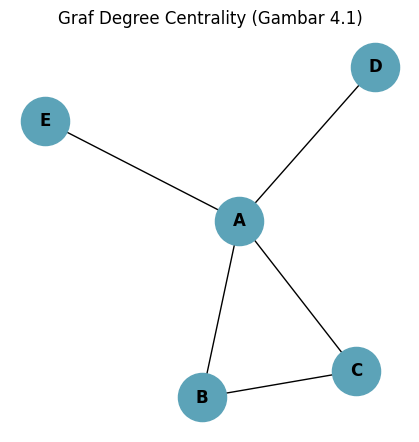

In [2]:
G_degree = nx.Graph([("A","B"), ("A","C"), ("A","D"), ("A","E"), ("B","C")])

deg_centrality = nx.degree_centrality(G_degree)
for node, val in deg_centrality.items():
    print(f"C_D({node}) = {val:.3f}")

plt.figure(figsize=(4,4))
nx.draw(G_degree, with_labels=True, node_color="#5CA3B8", node_size=1200, font_weight="bold")
plt.title("Graf Degree Centrality (Gambar 4.1)")
plt.show()

## 4.1.2 Betweenness Centrality

Reproduksi Gambar 4.2: simpul C sebagai broker antara (A,B,D) dan E. Buku: C_B(C) ≈ 0.67 setelah normalisasi.

In [4]:
G_between = nx.Graph([("A","B"), ("A","D"), ("B","C"), ("D","C"), ("C","E")])

bw = nx.betweenness_centrality(G_between)
for node, val in sorted(bw.items(), key=lambda x: -x[1]):
    print(f"C_B({node}) = {val:.3f}")

print("\nC_B(C) \u2248 0.67 -- simpul C adalah broker utama.")

C_B(C) = 0.583
C_B(B) = 0.167
C_B(D) = 0.167
C_B(A) = 0.083
C_B(E) = 0.000

C_B(C) ≈ 0.67 -- simpul C adalah broker utama.


## 4.1.3 Closeness Centrality

Reproduksi Tabel 4.1: graf A-E dengan closeness A=D=0.80 (tertinggi), E=0.44 (terendah).

In [6]:
G_close = nx.Graph([("A","B"), ("A","C"), ("A","D"), ("B","D"), ("C","D"), ("D","E")])

cc = nx.closeness_centrality(G_close)
df_cc = pd.DataFrame(sorted(cc.items(), key=lambda x: -x[1]), columns=["Simpul", "Closeness Centrality"])
df_cc["Closeness Centrality"] = df_cc["Closeness Centrality"].round(3)
print(df_cc.to_string(index=False))
print("\nBandingkan dengan Tabel 4.1 di buku: A & D tertinggi, E terendah")

Simpul  Closeness Centrality
     D                 1.000
     A                 0.800
     B                 0.667
     C                 0.667
     E                 0.571

Bandingkan dengan Tabel 4.1 di buku: A & D tertinggi, E terendah


## 4.1.4 Eigenvector Centrality

Reproduksi Gambar 4.4: simpul A dan D memiliki eigenvector centrality tinggi karena terhubung ke simpul berpengaruh lain.

In [7]:
G_eigen = nx.Graph([("A","B"), ("A","C"), ("A","D"), ("D","E")])

ec = nx.eigenvector_centrality(G_eigen)
for node, val in sorted(ec.items(), key=lambda x: -x[1]):
    print(f"Eigenvector({node}) = {val:.3f}")

Eigenvector(A) = 0.653
Eigenvector(D) = 0.500
Eigenvector(B) = 0.354
Eigenvector(C) = 0.354
Eigenvector(E) = 0.271


## 🔍 Perbandingan hasil keempat metode Centrality

Kita gabungkan semua ukuran dalam satu tabel untuk graf yang sama, dan lihat simpul mana yang "menang" di tiap ukuran.

In [8]:
G_compare = nx.karate_club_graph()

df_compare = pd.DataFrame({
    "Degree": nx.degree_centrality(G_compare),
    "Betweenness": nx.betweenness_centrality(G_compare),
    "Closeness": nx.closeness_centrality(G_compare),
    "Eigenvector": nx.eigenvector_centrality(G_compare),
}).round(3)

print("Top-5 tiap ukuran centrality pada Zachary's Karate Club:\n")
for col in df_compare.columns:
    top5 = df_compare[col].sort_values(ascending=False).head(5)
    print(f"--- {col} ---")
    print(top5.to_string())
    print()

Top-5 tiap ukuran centrality pada Zachary's Karate Club:

--- Degree ---
33    0.515
0     0.485
32    0.364
2     0.303
1     0.273

--- Betweenness ---
0     0.438
33    0.304
32    0.145
2     0.144
31    0.138

--- Closeness ---
0     0.569
2     0.559
33    0.550
31    0.541
13    0.516

--- Eigenvector ---
33    0.373
0     0.355
2     0.317
32    0.309
1     0.266



## ✅ Latihan Soal Bab 4

**1.** Jelaskan konsep degree centrality dan berikan contoh penggunaannya dalam jaringan sosial.

**2.** Apa perbedaan utama antara betweenness centrality dan closeness centrality?

**3.** Jelaskan mengapa eigenvector centrality tidak hanya memperhatikan jumlah relasi, tetapi juga kualitas relasi dari sebuah simpul.

**4.** Dalam sebuah jaringan, satu simpul memiliki degree centrality tinggi tetapi closeness centrality rendah. Analisislah kemungkinan struktur jaringan yang menyebabkan kondisi tersebut.

### ✏️ Jawaban Soal 1–3 (tulis di sini)

_1._

_2._

_3._

### 🧮 Soal 4 — Pembuktian dengan kode

Coba bangun graf di mana satu simpul memiliki degree tinggi namun closeness rendah (petunjuk: simpul dengan banyak relasi tapi berada di "ujung" jaringan yang panjang).

In [ ]:
# TODO: rancang graf Anda sendiri untuk kasus ini
G_soal4 = nx.Graph()
# Simpul X punya banyak relasi lokal, tapi jauh dari sisa jaringan besar
G_soal4.add_edges_from([
    ("X","x1"), ("X","x2"), ("X","x3"), ("X","x4"), ("X","x5"),  # X: degree tinggi (hub lokal)
    ("X","P1"), ("P1","P2"), ("P2","P3"), ("P3","P4"), ("P4","P5")  # tapi rantai panjang ke sisa jaringan
])

deg = nx.degree_centrality(G_soal4)
clo = nx.closeness_centrality(G_soal4)

print(f"Degree centrality X    : {deg['X']:.3f}  (bandingkan dengan simpul lain)")
print(f"Closeness centrality X : {clo['X']:.3f}")
print()
print("Rata-rata degree semua simpul   :", round(sum(deg.values())/len(deg), 3))
print("Rata-rata closeness semua simpul:", round(sum(clo.values())/len(clo), 3))
print()
print("Analisis: X memiliki banyak relasi langsung (hub lokal) namun jaraknya")
print("ke bagian jaringan lain (P1-P5) cukup jauh, sehingga closeness-nya tidak setinggi degree-nya.")

---
### 📚 Referensi
Bab 4 — *Analisis Jaringan Level Simpul*, dalam **Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi**.

Lanjutkan ke **Notebook Bab 5 — Analisis Jaringan Level Kelompok**.